In [1]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==========================================
# 0. 字体设置
# ==========================================
plt.rcParams['font.sans-serif'] = ['SimHei']  # 正常显示中文
plt.rcParams['axes.unicode_minus'] = False

# 如果你有下载好的好看的数字字体(例如特殊设计的粗体字)，可以通过下面这种方式加载：
# from matplotlib import font_manager
# num_font = font_manager.FontProperties(fname="你的字体文件路径/某字体.ttf", size=32)
# 这里为了通用，我们暂时使用系统中常见的英文字体 'Arial Black' 或 'Impact'

## 模拟图例（16城区）

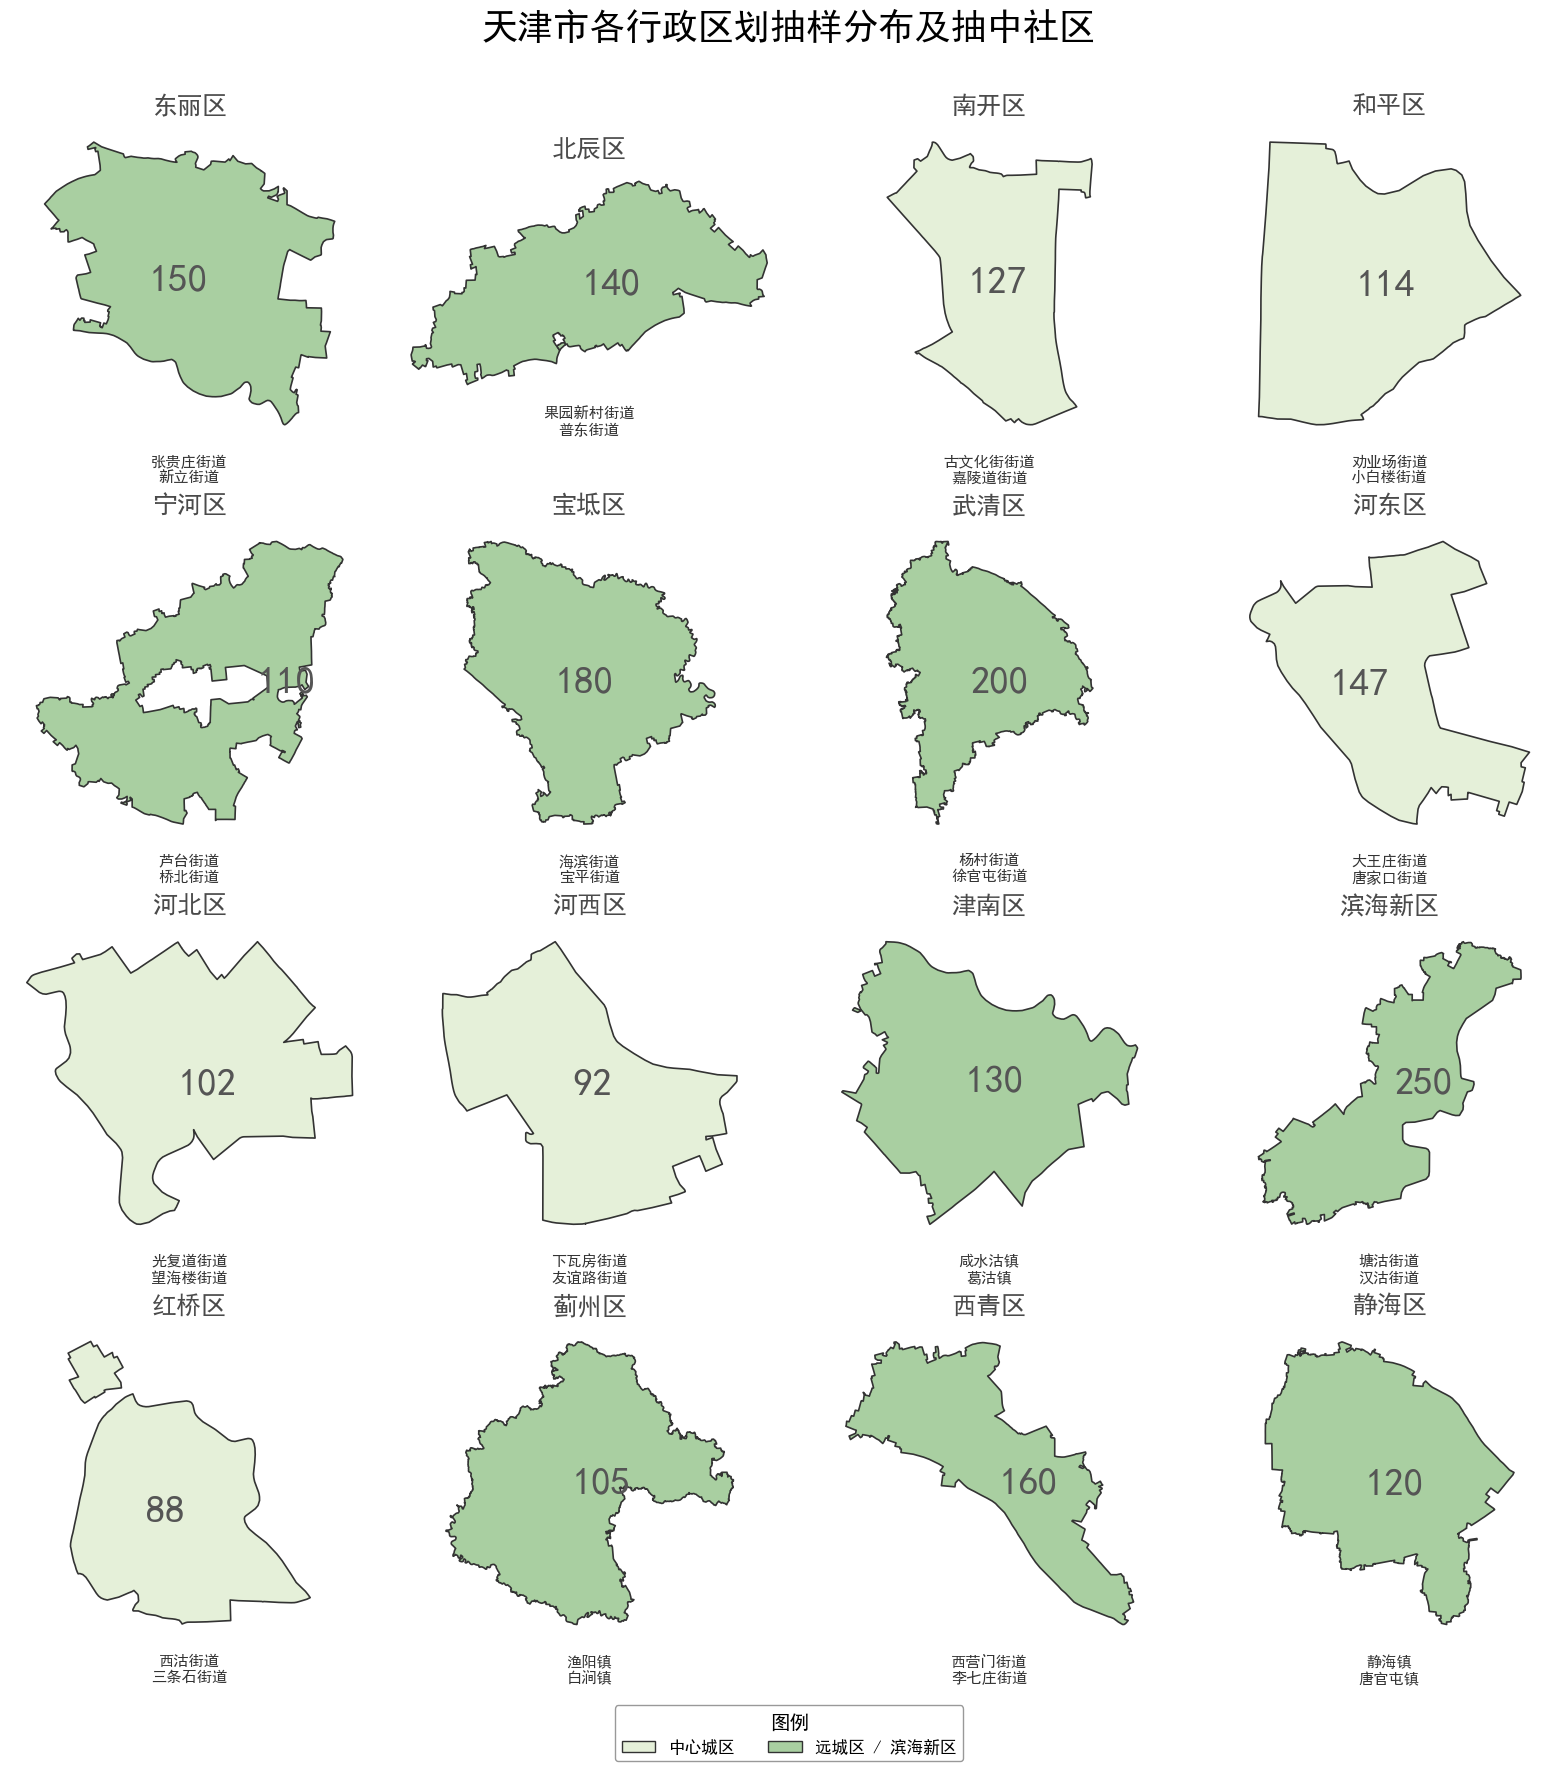

In [ ]:
# ==========================================
# 2. 准备模拟的业务数据 (实际应用中请替换为你真实的 Excel/CSV 数据)
# ==========================================
districts = [
    '和平区', '河东区', '河西区', '南开区', '河北区', '红桥区', 
    '东丽区', '西青区', '津南区', '北辰区', '武清区', '宝坻区', 
    '滨海新区', '宁河区', '静海区', '蓟州区'
]

# 模拟抽样数和区域分类 (center=中心城区浅绿色, far=远城区深绿色)
mock_data = {
    'district_name': districts,
    'sample_size': [114, 147, 92, 127, 102, 88, 150, 160, 130, 140, 200, 180, 250, 110, 120, 105],
    'color_type': ['center']*6 + ['far']*10,
    'communities': [
        '劝业场街道\n小白楼街道', '大王庄街道\n唐家口街道', '下瓦房街道\n友谊路街道', 
        '古文化街街道\n嘉陵道街道', '光复道街道\n望海楼街道', '西沽街道\n三条石街道', 
        '张贵庄街道\n新立街道', '西营门街道\n李七庄街道', '咸水沽镇\n葛沽镇', 
        '果园新村街道\n普东街道', '杨村街道\n徐官屯街道', '海滨街道\n宝平街道', 
        '塘沽街道\n汉沽街道', '芦台街道\n桥北街道', '静海镇\n唐官屯镇', 
        '渔阳镇\n白涧镇'
    ]
}
df_data = pd.DataFrame(mock_data)

# ==========================================
# 3. 读取并合并所有 GeoJSON 文件
# ==========================================
folder_path = 'tianjin_geojson/' # 请确保此文件夹存在且包含你的 .json 文件
gdf_list = []

# 遍历文件夹读取地图数据
if os.path.exists(folder_path):
    for filename in os.listdir(folder_path):
        if filename.endswith('.json'):
            file_path = os.path.join(folder_path, filename)
            try:
                gdf_part = gpd.read_file(file_path)
                gdf_list.append(gdf_part)
            except Exception as e:
                print(f"读取 {filename} 失败: {e}")
else:
    print(f"找不到文件夹 '{folder_path}'，请先创建并放入 json 文件！")

if not gdf_list:
    raise ValueError("没有成功读取到任何地图数据，请检查文件夹路径和文件格式。")

# 将所有单独的区合并为一个 GeoDataFrame
gdf_tj = pd.concat(gdf_list, ignore_index=True)
gdf_tj = gdf_tj.to_crs("EPSG:4326") # 统一坐标系

# 重命名 GeoDataFrame 中的 name 列以匹配我们的数据 df，并进行合并
gdf_tj = gdf_tj.rename(columns={'name': 'district_name'})
merged_gdf = gdf_tj.merge(df_data, on='district_name', how='inner')

# ==========================================
# 4. 开始绘制多面板图表 (4行4列网格)
# ==========================================
# 动态计算需要的行数和列数 (以防文件不足16个)
num_areas = len(merged_gdf)
cols = 4
rows = (num_areas + cols - 1) // cols 

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 4 * rows), constrained_layout=True)
axes = axes.flatten() # 将多维数组展平，方便遍历

# 遍历合并后的地理数据进行单独绘制
for idx, row in merged_gdf.iterrows():
    ax = axes[idx]
    
    # 提取当前区的数据
    dist_name = row['district_name']
    sample_size = row['sample_size']
    comm_text = row['communities']
    color_type = row['color_type']
    
    # 将当前行的数据转回 GeoDataFrame 用于画图
    single_area_gdf = gpd.GeoDataFrame([row], crs=merged_gdf.crs)
    
    # 设定颜色 (和示例图相近的浅绿与深绿)
    face_color = '#E5F0D9' if color_type == 'center' else '#A9CFA1'
    
    # a. 绘制地图轮廓
    single_area_gdf.plot(ax=ax, color=face_color, edgecolor='#333333', linewidth=1.2)
    
    # b. 添加顶部区名
    ax.set_title(dist_name, fontsize=18, fontweight='bold', pad=10, color='#4A4A4A')
    
    # c. 添加中心大字号的抽样数
    # 为了避免图形不规则导致中心点偏移，使用 representative_point() 往往比 centroid 更好
    center_point = single_area_gdf.geometry.representative_point().iloc[0]
    ax.text(center_point.x, center_point.y, str(sample_size), 
            fontsize=28, fontweight='900', ha='center', va='center', color='#555555')
    
    # d. 添加底部社区名
    # bbox_inches 等会自动处理超出的文本，但在轴上我们可以放在坐标轴的负 y 位置
    ax.text(0.5, -0.05, comm_text, transform=ax.transAxes, 
            fontsize=11, color='#333333', ha='center', va='top')
    
    # e. 隐藏坐标轴边框和刻度
    ax.axis('off')

# 隐藏多余的空白子图 (如果区域少于16个)
for i in range(num_areas, len(axes)):
    fig.delaxes(axes[i])

# ==========================================
# 5. 绘制全局图例
# ==========================================
center_patch = mpatches.Patch(color='#E5F0D9', label='中心城区', ec='#333333', lw=1)
far_patch = mpatches.Patch(color='#A9CFA1', label='远城区 / 滨海新区', ec='#333333', lw=1)

# 在图表底部中心添加图例
fig.legend(handles=[center_patch, far_patch], 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.05), # 微调图例位置使其在图表正下方
           ncol=2, 
           title='图例', 
           title_fontsize=14,
           fontsize=12,
           frameon=True, 
           edgecolor='gray')

fig.suptitle('天津市各行政区划抽样分布及抽中社区', fontsize=26, fontweight='bold', y=1.05)

# 显示图表
plt.show()

## 8城区

In [2]:
# ==========================================
# 1. 准备你要绘制的 8 个区的数据 (5中心 + 3远城)
# ==========================================
selected_districts = [
    '和平区', '河西区', '南开区', '西青区', '北辰区',  # 5个中心城区
    '蓟州区', '滨海新区', '静海区'                   # 3个远城区
]

mock_data = {
    'district_name': selected_districts,
    'sample_size': [114, 147, 92, 127, 102, 160, 250, 105], # 模拟抽样数
    'color_type': ['center']*5 + ['far']*3, # 前5个中心，后3个远城
    'communities': [
        '劝业场街道\n小白楼街道\n新兴街道', '大营门街道\n下瓦房街道\n梅江街道', 
        '鼓楼街道\n万兴街道\n体育中心街道', '西营门街道\n李七庄街道\n津门湖街道', 
        '果园新村街道\n集贤里街道\n瑞景街道', '文昌街道\n渔阳镇\n洇溜镇', 
        '塘沽街道\n大港街道\n泰达街道', '华康街道\n朝阳街道\n静海镇'
    ]
}
df_data = pd.DataFrame(mock_data)

# ==========================================
# 2. 读取并合并 GeoJSON 文件
# ==========================================
folder_path = 'tianjin_geojson/' # 你的文件夹路径
gdf_list = []

for filename in os.listdir(folder_path):
    if filename.endswith('.json'):
        file_path = os.path.join(folder_path, filename)
        gdf_part = gpd.read_file(file_path)
        gdf_list.append(gdf_part)

gdf_tj = pd.concat(gdf_list, ignore_index=True).to_crs("EPSG:4326")
gdf_tj = gdf_tj.rename(columns={'name': 'district_name'})

# 这里使用 inner merge，只有在这8个区列表里的地图才会被保留下来！
merged_gdf = gdf_tj.merge(df_data, on='district_name', how='inner')



###  3*3

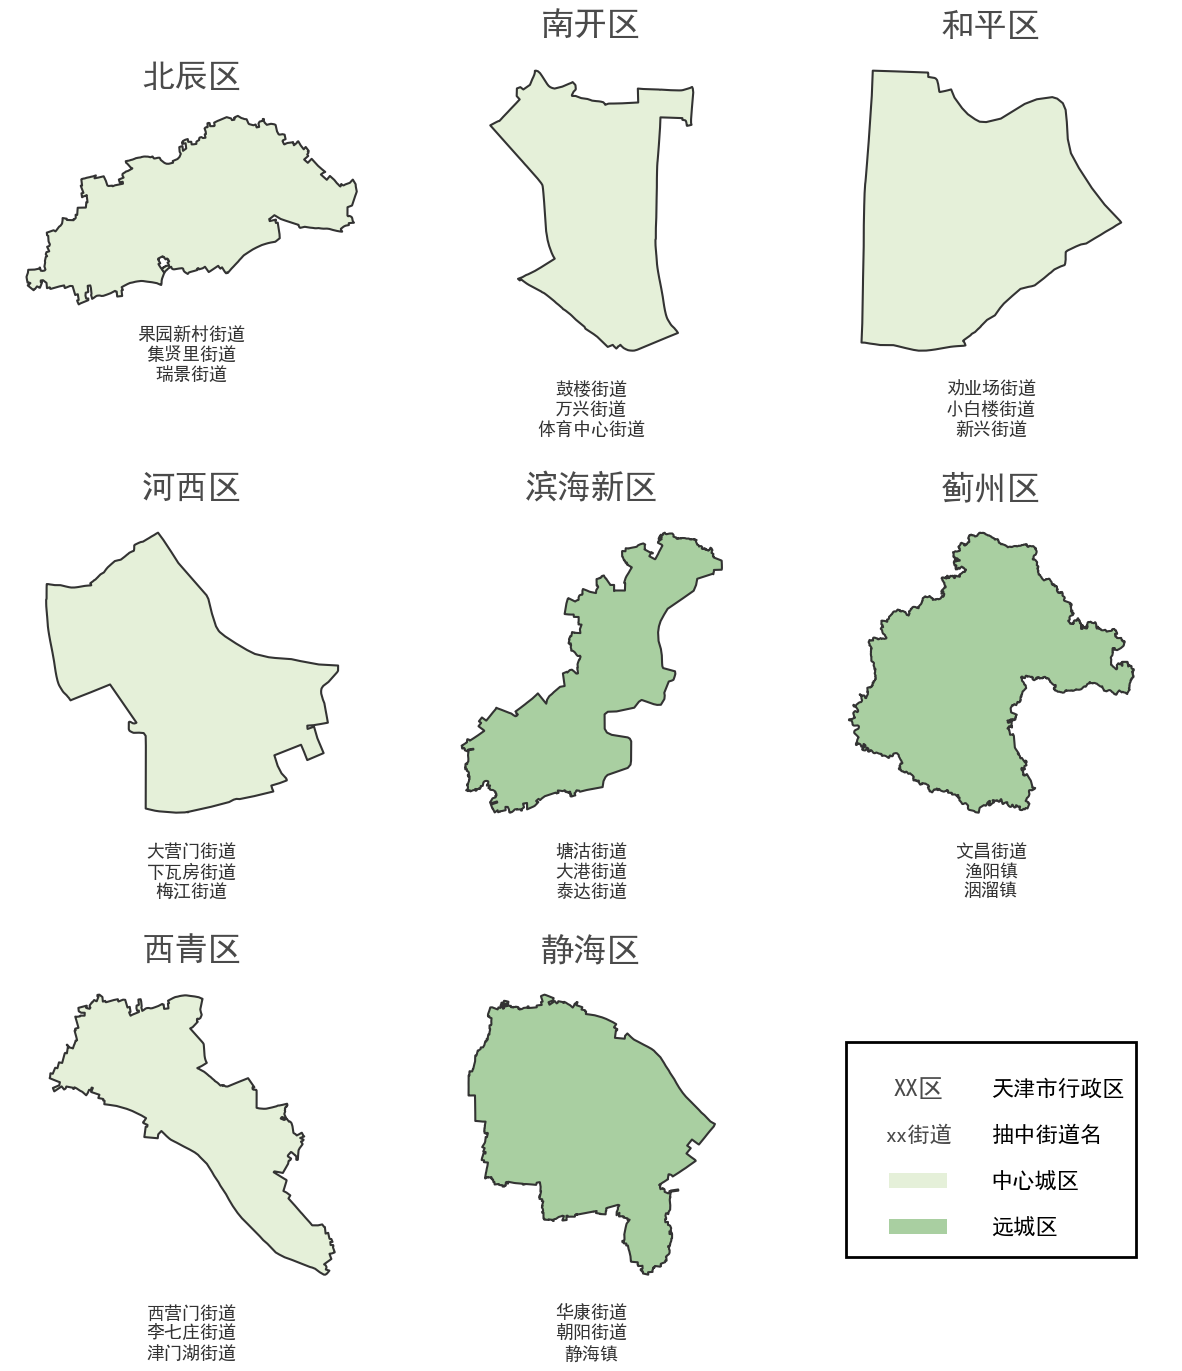

In [15]:
# ==========================================
# 3. 开始绘制 (3x3 网格)
# ==========================================
# 8个地图 + 1个大图例 = 9个格子，正好 3x3
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 16))
axes = axes.flatten()

# 统一的颜色配置
color_center = '#E5F0D9'
color_far = '#A9CFA1'

# a. 循环绘制前 8 个格子
for idx in range(len(merged_gdf)):
    row = merged_gdf.iloc[idx]
    ax = axes[idx]
    
    dist_name = row['district_name']
    sample_size = row['sample_size']
    comm_text = row['communities']
    color_type = row['color_type']
    
    single_area_gdf = gpd.GeoDataFrame([row], crs=merged_gdf.crs)
    face_color = color_center if color_type == 'center' else color_far
    
    # 画地图
    single_area_gdf.plot(ax=ax, color=face_color, edgecolor='#333333', linewidth=1.5)
    
    # 【需求3】区名加粗：fontweight='bold' 或 'heavy'
    ax.set_title(dist_name, fontsize=24, fontweight='heavy', pad=15, color='#4A4A4A')
    
    # 【需求4】修改数字字体：使用 family='Impact' 或 'Arial Black'
    '''center_point = single_area_gdf.geometry.representative_point().iloc[0]
    ax.text(center_point.x, center_point.y, str(sample_size), 
            fontsize=36, 
            family='Impact',    # <--- 这里修改数字字体！
            fontweight='bold', 
            ha='center', va='center', color='#4A4A4A')'''
    
    # 底部社区名
    ax.text(0.5, -0.05, comm_text, transform=ax.transAxes, 
            fontsize=13, color='#333333', ha='center', va='top')
    
    ax.axis('off')

# ==========================================
# 4. 【需求2】绘制占据一个独立格子的大型自定义图例
# ==========================================
legend_ax = axes[8]  # 获取第9个格子 (右下角)
legend_ax.axis('off') # 关掉默认坐标轴

# 画一个黑色外框矩形 (占该子图宽度的80%，高度的80%)
rect = mpatches.Rectangle((0.1, 0.1), 0.8, 0.7, transform=legend_ax.transAxes, 
                          fill=False, edgecolor='black', linewidth=2)
legend_ax.add_patch(rect)

# 在图例框内添加文本和色块 (位置都是相对该格子的 0~1 比例)
x_left = 0.3    # 左侧图标/示例的 X 坐标
x_right = 0.5   # 右侧文字解释的 X 坐标
y1, y2, y3, y4 = 0.65, 0.5, 0.35, 0.20

# 第一行：XX区
legend_ax.text(x_left, y1, 'XX区', fontsize=18, fontweight='heavy', ha='center', va='center', color='#4A4A4A')
legend_ax.text(x_right, y1, '天津市行政区', fontsize=16, va='center')

# 第二行：102 数字 (使用和地图里一样的特殊字体)
#legend_ax.text(x_left, 0.60, '102', fontsize=22, family='Impact', fontweight='bold', ha='center', va='center', color='#4A4A4A')
#legend_ax.text(x_right, 0.60, '抽样数量', fontsize=16, va='center')

# 第三行：xx社区
legend_ax.text(x_left, y2, 'xx街道', fontsize=16, fontweight='bold', ha='center', va='center', color='#4A4A4A')
legend_ax.text(x_right, y2, '抽中街道名', fontsize=16, va='center')

# 第四行、第五行：色块 (去掉边框 ec='none'，并精准居中对齐)
rect_width = 0.16
rect_height = 0.05
rect_x_start = x_left - (rect_width / 2) # 精准计算起点，使其正好在 x_left 对齐

# 第四行：中心城区色块
legend_ax.add_patch(mpatches.Rectangle((rect_x_start, y3 - rect_height/2), rect_width, rect_height, transform=legend_ax.transAxes, color=color_center, ec='none'))
legend_ax.text(x_right, y3, '中心城区', fontsize=16, va='center')

# 第五行：远城区色块
legend_ax.add_patch(mpatches.Rectangle((rect_x_start, y4 - rect_height/2), rect_width, rect_height, transform=legend_ax.transAxes, color=color_far, ec='none'))
legend_ax.text(x_right, y4, '远城区', fontsize=16, va='center')

# ==========================================
# 5. 最终布局调整
# ==========================================
# 调整子图间距
plt.subplots_adjust(wspace=0.1, hspace=0.5)

# 可以在最上面加个大标题（可选）
# fig.suptitle('天津市部分行政区划抽样分布及抽中社区', fontsize=26, fontweight='bold', y=0.95)

# 1. 保存为 PNG 格式（推荐，无损且清晰）
# dpi=300 表示设置分辨率为 300 (高清印刷级别)
# bbox_inches='tight' 会自动裁剪掉图像边缘多余的白色空白
plt.savefig('tianjin_3_3.png', dpi=300, bbox_inches='tight')

# 如果你需要其他格式，也可以取消下面对应行的注释：
# plt.savefig('tianjin_sample_map.jpg', dpi=300, bbox_inches='tight') # 保存为 JPG
# plt.savefig('tianjin_sample_map.pdf', bbox_inches='tight') # 保存为 PDF 矢量图，放大不失真，适合写论文


plt.show()

### 2*4 底部

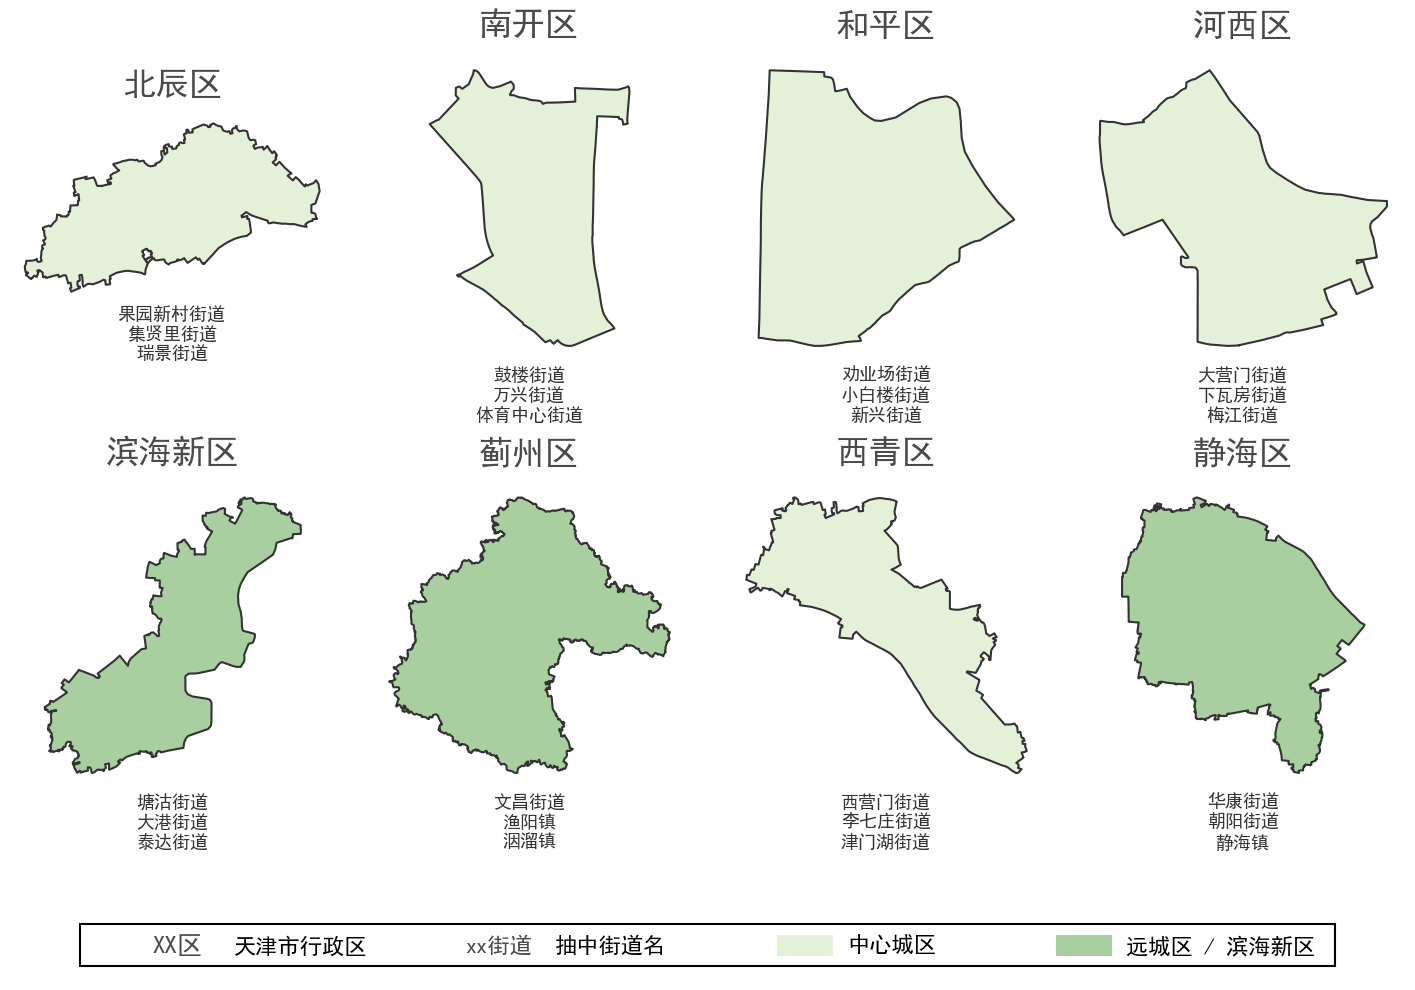

In [16]:
# ==========================================
# 3. 开始绘制 (使用 GridSpec 实现 2x4 地图 + 底部图例)
# ==========================================
# 创建图表，宽18，高10
fig = plt.figure(figsize=(18, 12))

# 创建 3行4列 的网格。height_ratios=[1, 1, 0.15] 代表前两行(地图)高，第3行(图例)极扁
gs = fig.add_gridspec(3, 4, height_ratios=[1, 1, 0.23])

color_center = '#E5F0D9'
color_far = '#A9CFA1'

# 提取用于画地图的 8 个坐标轴
axes = []
for i in range(2):      # 2行
    for j in range(4):  # 4列
        ax = fig.add_subplot(gs[i, j])
        axes.append(ax)

# a. 循环绘制 8 个区的地图
for idx in range(len(merged_gdf)):
    row = merged_gdf.iloc[idx]
    ax = axes[idx]
    
    dist_name = row['district_name']
    comm_text = row['communities']
    color_type = row['color_type']
    
    single_area_gdf = gpd.GeoDataFrame([row], crs=merged_gdf.crs)
    face_color = color_center if color_type == 'center' else color_far
    
    single_area_gdf.plot(ax=ax, color=face_color, edgecolor='#333333', linewidth=1.5)
    
    ax.set_title(dist_name, fontsize=24, fontweight='heavy', pad=15, color='#4A4A4A')
    
    # 底部社区名
    ax.text(0.5, -0.02, comm_text, transform=ax.transAxes, 
            fontsize=13, color='#333333', ha='center', va='top')
    
    ax.axis('off')


# ==========================================
# 4. 在底部绘制横向的全局大图例
# ==========================================
# 选中第3行 (索引为2)，横跨所有列 (:)
legend_ax = fig.add_subplot(gs[2, :])  
legend_ax.axis('off') 

# 画一个长条形的黑色外框矩形包围图例
rect = mpatches.Rectangle((0.05, 0.2), 0.9, 0.6, transform=legend_ax.transAxes, 
                          fill=False, edgecolor='black', linewidth=1.5)
legend_ax.add_patch(rect)

# 图例元素横向排布 (x坐标从左到右依次增加)
y_center = 0.5  # 统一的垂直中心

# 1. XX区
legend_ax.text(0.12, y_center, 'XX区', fontsize=18, fontweight='heavy', ha='center', va='center', color='#4A4A4A')
legend_ax.text(0.16, y_center, '天津市行政区', fontsize=16, va='center')

# 2. xx社区
legend_ax.text(0.35, y_center, 'xx街道', fontsize=16, fontweight='bold', ha='center', va='center', color='#4A4A4A')
legend_ax.text(0.39, y_center, '抽中街道名', fontsize=16, va='center')

# 色块的大小设置
rect_w = 0.04  # 宽度比例
rect_h = 0.3   # 高度比例
rect_y_start = y_center - (rect_h / 2) # 保证色块垂直居中

# 3. 中心城区色块
legend_ax.add_patch(mpatches.Rectangle((0.55, rect_y_start), rect_w, rect_h, transform=legend_ax.transAxes, color=color_center, ec='none'))
legend_ax.text(0.60, y_center, '中心城区', fontsize=16, va='center')

# 4. 远城区色块
legend_ax.add_patch(mpatches.Rectangle((0.75, rect_y_start), rect_w, rect_h, transform=legend_ax.transAxes, color=color_far, ec='none'))
legend_ax.text(0.80, y_center, '远城区 / 滨海新区', fontsize=16, va='center')

# ==========================================
# 5. 最终布局调整
# ==========================================
# 调整行间距 (hspace) 和 列间距 (wspace)
fig.subplots_adjust(wspace=0.1, hspace=0.55)

plt.savefig('tianjin_2_4.png', dpi=300, bbox_inches='tight')
plt.show()